In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

from einops import rearrange
from matplotlib.colors import ListedColormap

from utils import *

with open(obs_labels_path, "rb") as f:
    obs_data_dict = pickle.load(f)

with open(attack_labels_path, "rb") as f:
    beh_data_dict = pickle.load(f)

setup_plot_style()

In [3]:
fps = 40
# mouse_id_list = [*label_to_cond_dict.keys()] #[k for k, v in label_to_cond_dict.items() if v == "obs"]
stacked_pred_full = {}
d9_attack_labels = {}

for idx, (mouse_id, cond) in enumerate(label_to_cond_dict.items()):
    pred_full = obs_data_dict[mouse_id]
    mouse_diff = []
    stacked_pred_mice = []
    d9_attack_mice = []
    
    for d_idx in np.arange(1, 9):
        for s_idx in np.arange(1, 4):
            pred_d_s = pred_full[(pred_full["day_id"] == d_idx) & (pred_full["session_id"] == s_idx)]
            
            if len(pred_d_s) > 0:
                pred_d_s_pred_smpl = label_to_categories(pred_d_s['prediction'])
                if cond == "obs":
                    attack_labels_d_s = beh_data_dict[f'{mouse_id}_d{d_idx}_obs_t{s_idx}']['attack labels']
                else:
                    attack_label_d_s = np.zeros(pred_d_s["prediction"].shape[0])
                diff = pred_d_s["prediction"].shape[0] - attack_labels_d_s.shape[0]
                
                if diff < 0:
                    print(f"{mouse_id}, Day {d_idx}, Session {s_idx}, skipped due to missing frames")
                else:
                    mouse_diff.append(diff / fps)
                    stacked_arr = np.stack([pred_d_s_pred_smpl[diff: ], attack_labels_d_s])
                    stacked_pred_mice.append(stacked_arr)
            else:
                print(f"{mouse_id}, Day {d_idx}, Session {s_idx}, skipped due to missing prediction")
    for s_idx in np.arange(1, 4):
        d9_cond = "OBSm" if cond == "obs" else "xpo"
        attack_labels_d_s = beh_data_dict[f'{mouse_id}_d9_{d9_cond}CD1_t{s_idx}']['attack labels']
        d9_attack_mice.append(attack_labels_d_s)

    # print(mouse_id, np.round(np.sum(mouse_diff) / len(mouse_diff), 2))
    stacked_pred_full[mouse_id] = stacked_pred_mice
    d9_attack_labels[mouse_id] = d9_attack_mice

30R2, Day 2, Session 1, skipped due to missing frames
30R2, Day 4, Session 1, skipped due to missing frames
30R2, Day 8, Session 1, skipped due to missing frames
87L2, Day 8, Session 1, skipped due to missing frames
933R, Day 4, Session 2, skipped due to missing frames
933R, Day 5, Session 2, skipped due to missing frames
86L, Day 3, Session 1, skipped due to missing frames


In [ ]:
mouse_id_list = [key for key, value in [*label_to_cond_dict.items()] if value != 'xpo']

attn_prop_list = []
attn_attck_prop_list = []
d9_attack_prop_list = []
attack_prop_list = []

for mouse_id in mouse_id_list:
    combined_mouse_preds = np.concatenate(stacked_pred_full[mouse_id], axis=1)
    attn_prop = np.sum(combined_mouse_preds[0] == 1) / combined_mouse_preds.shape[1]
    attack_prop = np.sum(combined_mouse_preds[1] == 1) / combined_mouse_preds.shape[1]
    attn_attck_prop = np.sum((combined_mouse_preds[0] == 1) & (combined_mouse_preds[1] == 1)) / np.sum(combined_mouse_preds[1] == 1)

    d9_attack = np.concatenate(d9_attack_labels[mouse_id])
    d9_attack_prop = np.sum(d9_attack == 1) / d9_attack.shape[0]
    
    attn_prop_list.append(attn_prop)
    attn_attck_prop_list.append(np.sum(attn_attck_prop))
    d9_attack_prop_list.append(d9_attack_prop)
    attack_prop_list.append(attack_prop)

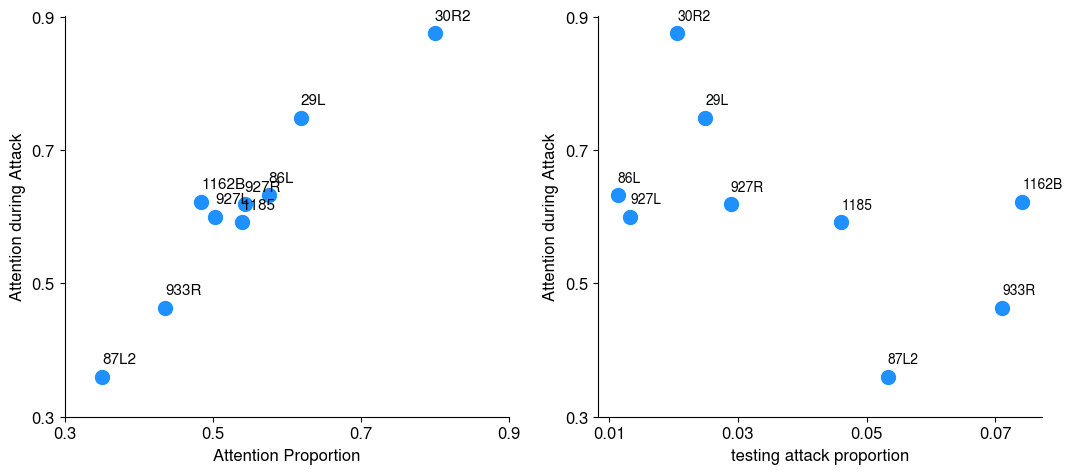

In [7]:
fig, axs = plt.subplots(1, 2, figsize = (11, 5))
font_size = 12
for i, mouse_id in enumerate(mouse_id_list):
    marker = "o" if label_to_cond_dict[mouse_id] == "obs" else "s"
    axs[0].scatter(attn_prop_list[i], attn_attck_prop_list[i], 
                   color = "dodgerblue", s = 100, marker = marker)
for i, mouse_id in enumerate(mouse_id_list):
    axs[0].text(attn_prop_list[i], 
                attn_attck_prop_list[i] + .02, 
                mouse_id, fontsize = font_size - 1)
axs[0].set_xlabel("Attention Proportion", fontsize = font_size)
axs[0].set_ylabel("Attention during Attack", fontsize = font_size)
axs[0].set_xticks(np.arange(.3, .9, .2), np.round(np.arange(.3, .9, .2), 2), fontsize = font_size)
axs[0].set_yticks(np.arange(.3, 1, .2), np.round(np.arange(.3, 1, .2), 2), fontsize = font_size)

# Plot points with different markers for different conditions
for i, mouse_id in enumerate(mouse_id_list):
    marker = "o" if label_to_cond_dict[mouse_id] == "obs" else "s"
    axs[1].scatter(d9_attack_prop_list[i], attn_attck_prop_list[i], 
                   color="dodgerblue", s = 100, marker=marker)
for i, mouse_id in enumerate(mouse_id_list):
    axs[1].text(d9_attack_prop_list[i], 
                attn_attck_prop_list[i] + .02, 
                mouse_id, fontsize = font_size - 2)
axs[1].set_xlabel("testing attack proportion", fontsize = font_size)
axs[1].set_ylabel("Attention during Attack", fontsize = font_size)

axs[1].set_xticks(np.arange(0.01, 0.08, 0.02), np.round(np.arange(0.01, 0.08, 0.02), 2), fontsize = font_size)
axs[1].set_yticks(np.arange(.3, 1, .2), np.round(np.arange(.3, 1, .2), 2), fontsize = font_size)

plt.tight_layout()
sns.despine()
plt.show()

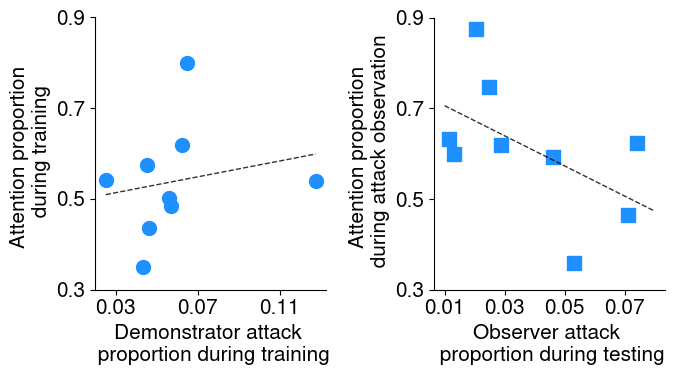

In [ ]:
# Prepare data for both subplots
x1 = np.array(attack_prop_list)
y1 = np.array(attn_prop_list)
x2 = np.array(d9_attack_prop_list)
y2 = np.array(attn_attck_prop_list)

fig, axs = plt.subplots(1, 2, figsize=(7, 4))

font_size = 15
# --- Subplot 1: attn vs attack (attention proportion vs attention during attack) ---
# Linear regression for subplot 1
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x1, y1)
x1_plot = np.linspace(x1.min(), x1.max(), 100)
y1_pred = slope1 * x1_plot + intercept1

for i, mouse_id in enumerate(mouse_id_list):
    marker = "o" if label_to_cond_dict[mouse_id] == "obs" else "s"
    axs[0].scatter(x1[i], y1[i], color="dodgerblue", s=100, marker=marker)
axs[0].plot(x1_plot, y1_pred, color="black", linestyle="--", alpha=.8, linewidth=1,
            label=f"Slope: {slope1:.2f}, R²: {r_value1**2:.2f}, P: {p_value1:.2f}")
# for i, mouse_id in enumerate(mouse_id_list):
#     axs[0].text(x1[i], y1[i] + .02, mouse_id, fontsize=font_size - 2)
axs[0].set_xlabel("Demonstrator attack \n proportion during training", fontsize=font_size)
axs[0].set_ylabel("Attention proportion \n during training", fontsize=font_size)
axs[0].set_xticks(np.arange(0.03, 0.13, 0.04), np.round(np.arange(0.03, 0.13, 0.04), 2), fontsize=font_size)
axs[0].set_yticks(np.arange(.3, 1, .2), np.round(np.arange(.3, 1, .2), 2), fontsize=font_size)
# axs[0].legend()

# --- Subplot 2: keep current code: d9_attack_prop_list vs attn_attck_prop_list ---
# Linear regression for subplot 2
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x2, y2)
x2_plot = np.linspace(0.01, 0.08, 100)
y2_pred = slope2 * x2_plot + intercept2

for i, mouse_id in enumerate(mouse_id_list):
    axs[1].scatter(x2[i], y2[i], color="dodgerblue", s=100, marker = "s")
axs[1].plot(x2_plot, y2_pred, color="black", linestyle="dashed", alpha=.8, linewidth=1,
            label=f"Slope: {slope2:.2f}, R²: {r_value2**2:.2f}, P: {p_value2:.2f}")

axs[1].set_xlabel("Observer attack \n proportion during testing", fontsize=font_size)
axs[1].set_ylabel("Attention proportion \n during attack observation", fontsize=font_size)
axs[1].set_xticks(np.arange(0.01, 0.08, 0.02), np.round(np.arange(0.01, 0.08, 0.02), 2), fontsize=font_size)
axs[1].set_yticks(np.arange(.3, 1, .2), np.round(np.arange(.3, 1, .2), 2), fontsize=font_size)

plt.tight_layout()
sns.despine()

plt.savefig(os.path.join(fig_pub_path, "attack_attn_correlation.svg"), format="svg")
plt.show()